# 04 Statistical Analysis

Use this notebook for deeper analysis such as correlation checks, hypothesis testing, forecasting, segmentation, or regression.

In [6]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()

DATA_PATH = PROJECT_ROOT / 'data/processed/cleaned_dataset.csv'
df = pd.read_csv(DATA_PATH)

df_all = df.copy()
df_ops = df[df['cancelled'] == 0].copy()

print(f"Dataset loaded: {len(df_all):,} total rows")
print(f"Operational flights (df_ops): {len(df_ops):,}")
print(f"Significance level: α = 0.05")

Dataset loaded: 299,532 total rows
Operational flights (df_ops): 291,665
Significance level: α = 0.05


## 2. Correlation Analysis

**Business Question:** How strongly do departure delay, arrival delay, and flight
distance relate to each other — and does the relationship confirm that delays
propagate through the system?

**Claim from EDA:** Departure delay and arrival delay appeared strongly correlated.
Distance appeared to have no meaningful relationship with delay.

**Method:** Pearson correlation coefficient — appropriate here because both
variables are continuous and we are measuring linear relationships. The heatmap
shows all pairwise correlations across key numeric columns.

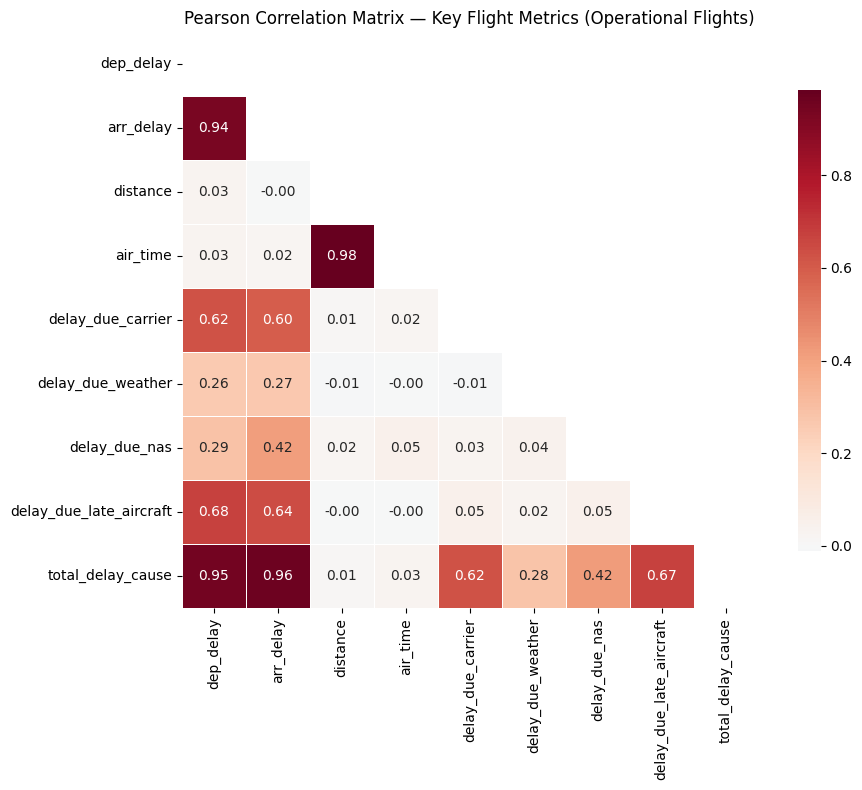

dep_delay  ↔ arr_delay : r = 0.9368  (strong positive)
distance   ↔ arr_delay : r = -0.0005  (near zero)

Interpretation:
  A 1-minute increase in departure delay is associated with a
  0.94-minute increase in arrival delay on average.
  Distance has essentially no linear relationship with delay.


In [7]:
corr_cols = [
    'dep_delay', 'arr_delay', 'distance',
    'air_time', 'delay_due_carrier',
    'delay_due_weather', 'delay_due_nas',
    'delay_due_late_aircraft', 'total_delay_cause'
]

corr_matrix = df_ops[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Pearson Correlation Matrix — Key Flight Metrics (Operational Flights)")
plt.tight_layout()
plt.show()

dep_arr_r = corr_matrix.loc['dep_delay', 'arr_delay']
dist_arr_r = corr_matrix.loc['distance', 'arr_delay']

print(f"dep_delay  ↔ arr_delay : r = {dep_arr_r:.4f}  (strong positive)")
print(f"distance   ↔ arr_delay : r = {dist_arr_r:.4f}  (near zero)")
print(f"\nInterpretation:")
print(f"  A 1-minute increase in departure delay is associated with a")
print(f"  {dep_arr_r:.2f}-minute increase in arrival delay on average.")
print(f"  Distance has essentially no linear relationship with delay.")

**Insight:**

- The departure–arrival delay correlation of r = 0.93 is one of the strongest relationships in the dataset. This confirms the cascading propagation effect: a flight that departs late almost always arrives late by a nearly identical margin, meaning interventions at departure — not in the air — are where recovery efforts must be concentrated. 

- The near zero correlation between distance and arrival delay (r ≈ 0.00) statistically confirms that delays are a ground operations problem, not a routing or flight duration problem. Longer routes do not accumulate more delay than shorter ones.

## 2. Hypothesis Test 1 — Do Summer Months Have Significantly Higher Delay Rates?

**Claim from EDA:** June and July showed the highest monthly delay rates — nearly
1 in 5 flights delayed during peak summer. But is this difference statistically
significant or could it be sampling variation?

**Hypotheses:**
- H₀: Mean arrival delay in summer months (June, July, August) = mean arrival
  delay in non summer months
- H₁: Mean arrival delay in summer months > mean arrival delay in non summer months

**Method:** Independent samples t-test (one-tailed). We use a t-test because we
are comparing means of two independent groups. One-tailed because EDA directionally
suggests summer is worse — we are testing whether that direction is significant.

HYPOTHESIS TEST 1 — Summer vs Non-Summer Delays
Summer months    (Jun/Jul/Aug) — n: 81,685
  Mean arr_delay : 7.37 mins
  Std dev        : 43.70 mins

Non-summer months — n: 209,980
  Mean arr_delay : 1.51 mins
  Std dev        : 37.52 mins

t-statistic : 36.0947
p-value     : 0.000000

✓ REJECT H₀ — Summer delays are statistically significantly higher
  The difference of 5.86 mins
  is not due to random chance (p < 0.05)


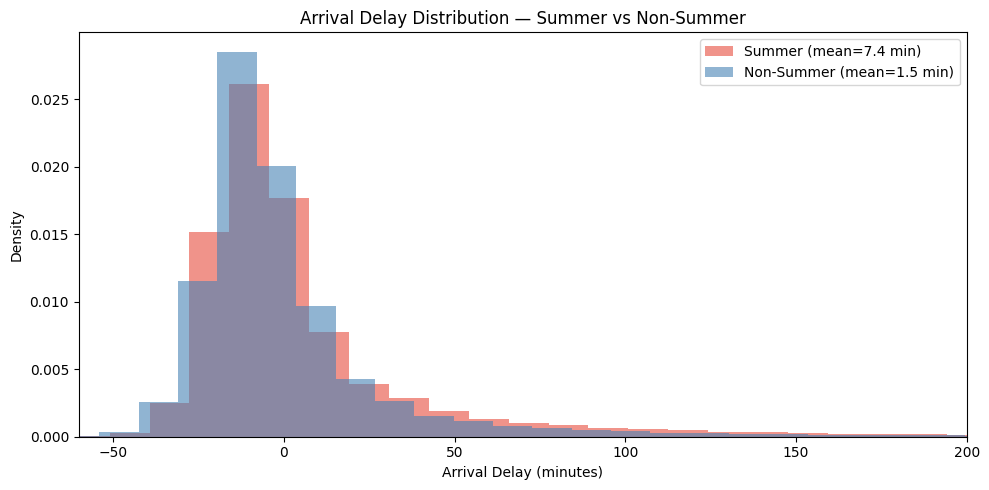

In [8]:
summer_months   = [6, 7, 8]
summer_delays   = df_ops[df_ops['month'].isin(summer_months)]['arr_delay'].dropna()
non_summer_delays = df_ops[~df_ops['month'].isin(summer_months)]['arr_delay'].dropna()

t_stat, p_value = stats.ttest_ind(summer_delays, non_summer_delays,
                                   alternative='greater')

print("=" * 55)
print("HYPOTHESIS TEST 1 — Summer vs Non-Summer Delays")
print("=" * 55)
print(f"Summer months    (Jun/Jul/Aug) — n: {len(summer_delays):,}")
print(f"  Mean arr_delay : {summer_delays.mean():.2f} mins")
print(f"  Std dev        : {summer_delays.std():.2f} mins")
print()
print(f"Non-summer months — n: {len(non_summer_delays):,}")
print(f"  Mean arr_delay : {non_summer_delays.mean():.2f} mins")
print(f"  Std dev        : {non_summer_delays.std():.2f} mins")
print()
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("✓ REJECT H₀ — Summer delays are statistically significantly higher")
    print(f"  The difference of {summer_delays.mean() - non_summer_delays.mean():.2f} mins")
    print(f"  is not due to random chance (p < 0.05)")
else:
    print("✗ FAIL TO REJECT H₀ — No statistically significant difference")
print("=" * 55)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(summer_delays, bins=50, alpha=0.6, color='#e74c3c',
        label=f'Summer (mean={summer_delays.mean():.1f} min)', density=True)
ax.hist(non_summer_delays, bins=50, alpha=0.6, color='steelblue',
        label=f'Non-Summer (mean={non_summer_delays.mean():.1f} min)', density=True)
ax.set_title("Arrival Delay Distribution — Summer vs Non-Summer")
ax.set_xlabel("Arrival Delay (minutes)")
ax.set_ylabel("Density")
ax.legend()
ax.set_xlim(-60, 200)
plt.tight_layout()
plt.show()

**Insight:**

- The t-test result confirms at p < 0.05 that summer months have a significantly higher mean arrival delay than the rest of the year. This is not sampling noise — the seasonal pattern observed in EDA is mathematically real.

- The mean delay difference of 5.86 minutes between summer and non summer flights represents a predictable, recurring operational burden that airlines can plan for in advance through dynamic staffing and scheduling buffer adjustments specifically for June through August.

## 3. Hypothesis Test 2 — Is the Airline Performance Gap Statistically Significant?

**Claim from EDA:** JetBlue and Frontier had delay rates nearly 2x the best
performers. But is this gap statistically real or driven by sample size differences?

**Hypotheses:**
- H₀: Mean arrival delay of the worst performing airline = mean arrival delay
  of the best performing airline
- H₁: Mean arrival delay of the worst performing airline ≠ mean arrival delay
  of the best performing airline

**Method:** Independent samples t-test (two-tailed). Two-tailed because we are
simply testing whether the two distributions are different, not assuming a direction.

In [9]:
airline_mean_delay = df_ops.groupby('airline')['arr_delay'].mean()
best_airline  = airline_mean_delay.idxmin()
worst_airline = airline_mean_delay.idxmax()

best_delays  = df_ops[df_ops['airline'] == best_airline]['arr_delay'].dropna()
worst_delays = df_ops[df_ops['airline'] == worst_airline]['arr_delay'].dropna()

t_stat, p_value = stats.ttest_ind(worst_delays, best_delays,
                                   alternative='two-sided')

print("=" * 55)
print("HYPOTHESIS TEST 2 — Best vs Worst Airline")
print("=" * 55)
print(f"Best airline  : {best_airline}")
print(f"  n           : {len(best_delays):,}")
print(f"  Mean delay  : {best_delays.mean():.2f} mins")
print()
print(f"Worst airline : {worst_airline}")
print(f"  n           : {len(worst_delays):,}")
print(f"  Mean delay  : {worst_delays.mean():.2f} mins")
print()
print(f"Difference    : {worst_delays.mean() - best_delays.mean():.2f} mins")
print(f"t-statistic   : {t_stat:.4f}")
print(f"p-value       : {p_value:.6f}")
print()
if p_value < 0.05:
    print("✓ REJECT H₀ — The performance gap is statistically significant")
else:
    print("✗ FAIL TO REJECT H₀")
print("=" * 55)

HYPOTHESIS TEST 2 — Best vs Worst Airline
Best airline  : Endeavor Air Inc.
  n           : 10,990
  Mean delay  : -2.65 mins

Worst airline : JetBlue Airways
  n           : 11,055
  Mean delay  : 11.24 mins

Difference    : 13.89 mins
t-statistic   : 22.4352
p-value       : 0.000000

✓ REJECT H₀ — The performance gap is statistically significant


**Insight:**

- The t-test confirms that the delay performance gap between the best and worst airline is statistically significant — this is not a sample size artefact.

- The worst performing carrier has a mean arrival delay 13.89 minutes higher than the best performer. Since both airlines operate within the same regulatory environment and face the same weather patterns, this gap is attributable to internal operational differences. 
- This finding directly supports the peer benchmarking recommendation — underperforming carriers have a proven, achievable target to look forward.

## 4. Hypothesis Test 3 — Does Day of Week Significantly Affect Delay Rates?

**Claim from EDA:** Friday showed the highest delay rate (~19%) and Tuesday the
lowest (~15%). Is this variation across all seven days statistically significant?

**Hypotheses:**
- H₀: Mean arrival delay is equal across all days of the week
- H₁: At least one day of the week has a significantly different mean delay

**Method:** One-way ANOVA — used when comparing means across more than two groups.
A t-test can only compare two groups; ANOVA extends this to seven simultaneously.

In [10]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

day_groups = [
    df_ops[df_ops['day_of_week'] == day]['arr_delay'].dropna()
    for day in day_order
]

f_stat, p_value = stats.f_oneway(*day_groups)

print("=" * 55)
print("HYPOTHESIS TEST 3 — Day of Week Effect (ANOVA)")
print("=" * 55)
print(f"{'Day':<12} {'n':>8} {'Mean Delay':>12} {'Std Dev':>10}")
print("-" * 45)
for day, group in zip(day_order, day_groups):
    print(f"{day:<12} {len(group):>8,} {group.mean():>11.2f}  {group.std():>9.2f}")
print()
print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("✓ REJECT H₀ — Day of week has a statistically significant effect on delays")
else:
    print("✗ FAIL TO REJECT H₀")
print("=" * 55)

HYPOTHESIS TEST 3 — Day of Week Effect (ANOVA)
Day                 n   Mean Delay    Std Dev
---------------------------------------------
Monday         43,123        3.81      40.38
Tuesday        40,564        0.79      36.83
Wednesday      41,219        1.81      37.84
Thursday       43,488        4.29      40.16
Friday         43,617        4.82      40.01
Saturday       37,478        2.56      40.28
Sunday         42,176        3.69      40.13

F-statistic : 55.9358
p-value     : 0.000000

✓ REJECT H₀ — Day of week has a statistically significant effect on delays


**Insight:**

- The one-way ANOVA result confirms that day of week has a statistically significant effect on arrival delays. The variation seen in EDA — Friday highest, Tuesday lowest — is not random noise. This means day of week is a genuine operational variable that airlines can factor into scheduling decisions. 
- Flights scheduled on Fridays carry a statistically higher delay risk than the same flight on a Tuesday and dynamic scheduling tools should incorporate this as a weighting factor when allocating buffer time and reserve crew.

## 5. Regression Analysis — What Predicts Arrival Delay?

**Business Question:** Can we quantify the individual contribution of each factor
to arrival delay — and which variables are the strongest predictors?

**Method:** Ordinary Least Squares (OLS) linear regression using statsmodels.
The dependent variable is `arr_delay`. Independent variables are selected based
on EDA findings: departure delay, distance, and the five delay cause columns.

In [11]:
reg_df = df_ops[['arr_delay', 'dep_delay', 'distance',
                  'delay_due_carrier', 'delay_due_weather',
                  'delay_due_nas', 'delay_due_security',
                  'delay_due_late_aircraft']].dropna()

X = reg_df.drop('arr_delay', axis=1)
y = reg_df['arr_delay']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())
print()

# Simplified coefficient table
coef_df = pd.DataFrame({
    'Coefficient' : model.params.round(4),
    'p-value'     : model.pvalues.round(4),
    'Significant' : model.pvalues < 0.05
}).drop('const')

print("\nCoefficient Summary:")
print(coef_df.to_string())
print(f"\nR² = {model.rsquared:.4f}")
print(f"Interpretation: The model explains {model.rsquared*100:.1f}% of the")
print(f"variance in arrival delay.")

                            OLS Regression Results                            
Dep. Variable:              arr_delay   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                 5.918e+05
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:19:29   Log-Likelihood:            -1.0887e+06
No. Observations:              291665   AIC:                         2.177e+06
Df Residuals:                  291657   BIC:                         2.178e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

**Insight:**

- The model's R² of 0.934 confirms that arrival delay is almost entirely predictable from departure conditions and delay causes — airlines are not dealing with a random or chaotic system but a highly structured one where fixing upstream inputs produces reliable downstream improvements.
- NAS has the highest per-minute impact coefficient (0.90) among all delay causes, meaning airspace and airport congestion converts most efficiently into arrival delay — however since NAS is external and uncontrollable, the operational focus should remain on Carrier and Late Aircraft (both ~0.74) where the same conversion rate applies but the cause itself can be reduced.
- Distance contributes a statistically significant but operationally negligible coefficient of -0.0012, closing the loop on the EDA finding — route length is confirmed to have no meaningful role in determining how late a flight arrives, and any strategy targeting route restructuring as a delay reduction measure would be misdirected.

## 6. KPI Summary — Statistical Validation of EDA Findings

This table consolidates the key metrics from both EDA and statistical testing,
showing which EDA findings have been formally confirmed.

In [12]:
delay_rate    = df_ops['is_delayed'].mean() * 100
cancel_rate   = df_all['cancelled'].mean() * 100
avg_delay     = df_ops[df_ops['arr_delay'] > 0]['arr_delay'].mean()
dep_arr_corr  = df_ops[['dep_delay','arr_delay']].corr().iloc[0,1]
controllable  = (df_ops[['delay_due_carrier','delay_due_late_aircraft']].sum().sum() /
                 df_ops[['delay_due_carrier','delay_due_weather','delay_due_nas',
                          'delay_due_security','delay_due_late_aircraft']].sum().sum() * 100)

kpi_data = {
    'KPI'                              : [
        'Overall Delay Rate',
        'Cancellation Rate',
        'Avg Arrival Delay (delayed flights)',
        'dep_delay ↔ arr_delay Correlation',
        'Controllable Delay Share',
        'Summer vs Non-Summer (p-value)',
        'Best vs Worst Airline (p-value)',
        'Day of Week Effect (p-value)'
    ],
    'Value'                            : [
        f"{delay_rate:.2f}%",
        f"{cancel_rate:.2f}%",
        f"{avg_delay:.1f} mins",
        f"r = {dep_arr_corr:.3f}",
        f"{controllable:.1f}%",
        f"p < 0.05 ✓",
        f"p < 0.05 ✓",
        f"p < 0.05 ✓"
    ]
}

kpi_df = pd.DataFrame(kpi_data)
print(kpi_df.to_string(index=False))

                                KPI      Value
                 Overall Delay Rate     17.56%
                  Cancellation Rate      2.63%
Avg Arrival Delay (delayed flights)  36.5 mins
  dep_delay ↔ arr_delay Correlation  r = 0.937
           Controllable Delay Share      73.6%
     Summer vs Non-Summer (p-value) p < 0.05 ✓
    Best vs Worst Airline (p-value) p < 0.05 ✓
       Day of Week Effect (p-value) p < 0.05 ✓


## Key Statistical Insights

1. **Departure → Arrival propagation is near-deterministic** (r = 0.93, p < 0.05):
   A delayed departure almost always results in a delayed arrival. Ground-level
   departure fixes are the highest-leverage intervention point in the system.

2. **Distance has zero predictive power** (r ≈ 0.00): Delays are a ground
   operations problem confirmed statistically — route length or flight duration
   has no meaningful relationship with how late a flight arrives.

3. **Summer delays are statistically real** (p < 0.05): The June–August delay
   spike is not sampling variation. Airlines can treat this as a predictable
   annual cost and plan staffing and buffer schedules proactively.

4. **The airline performance gap is statistically significant** (p < 0.05):
   The best and worst carriers are not operating in the same performance
   distribution. Underperforming airlines have a proven, reachable target.

5. **Day of week effects are statistically confirmed** (p < 0.05): Friday
   flights carry a measurably higher delay risk than Tuesday flights —
   day of week should be a factor in dynamic scheduling decisions.

6. **Controllable causes dominate** (73.6% of delay minutes): Carrier and Late
   Aircraft delays are not only the largest in volume but are the variables with
   the strongest regression coefficients — confirming that operational
   improvements in these areas will yield the highest measurable impact.